# Полиномиальная регрессия


**Задача регрессии** - это задача _обучения с учителем (supervised learning)_. Алгоритм предсказывает ответ (некоторое вещественное число) для каждого объекта на основе общей закономерности, найденной по конечному числу известных примеров. На предыдущем занятии изучили линейную регрессию. Здесь рассмотрим **полиномиальную регрессию**. Это тоже линейная модель, используется в случае нелинейной зависимости между признаками и ответом.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_context("paper", font_scale=1.2)

Сгенерируем данные (10 объектов), подчиняющиеся зависимости 3-го порядка. Добавим к ним шум.

In [3]:
def f(x):
    return 5.5 + 10.0 * x - 7.7 * x ** 2 + 3.3 * x ** 3

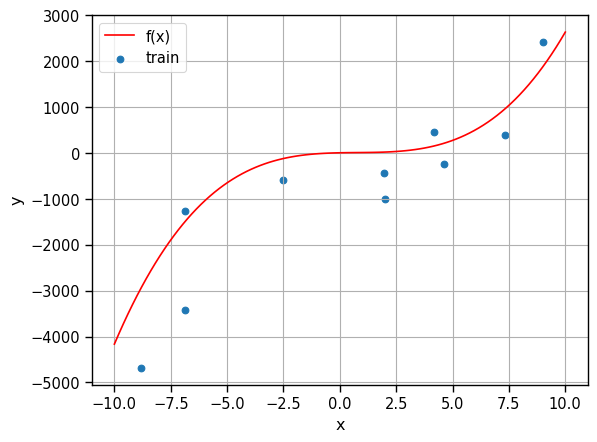

In [4]:
np.random.seed(42)
x = np.linspace(start=-10, stop=10, num=100)
plt.plot(x, f(x), 'r', label='f(x)')

x_train = np.random.uniform(low=-10, high=10, size=10)
y_train = f(x_train) + 1000 * np.random.randn(10)
plt.scatter(x_train, y_train, label='train')
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.legend();

Для начала создадим константную модель для восстановления исходной зависимости:
$$\hat y=w_0=\bar y.$$

In [5]:
len(x)

100

In [6]:
# [f(x).mean()] * len(x)

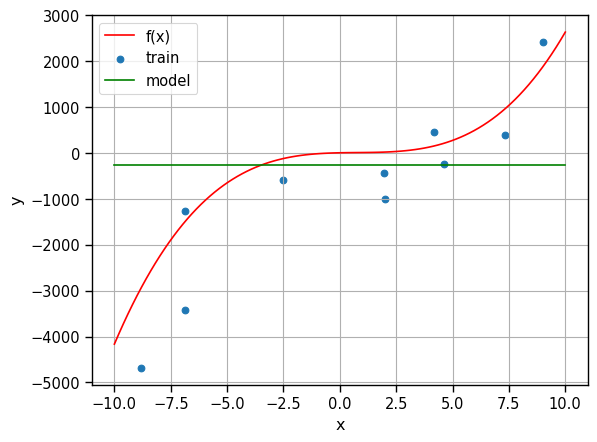

In [7]:
plt.plot(x, f(x), 'r', label='f(x)')
plt.scatter(x_train, y_train, label='train')
plt.plot(x, [f(x).mean()] * len(x), color='g', label='model')
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.legend();

Усложним модель, применив линейную регрессию:
$$\hat y=w_0+w_1\cdot x.$$

In [8]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(x_train.reshape(-1, 1), y_train)
y_train_pred = reg.predict(x_train.reshape(-1, 1))

In [9]:
reg.intercept_, reg.coef_[0]

(np.float64(-947.6773208545178), np.float64(281.69258219574937))

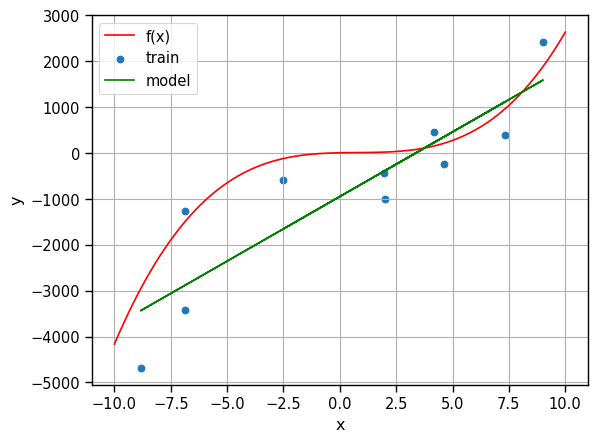

In [10]:
plt.plot(x, f(x), 'r', label='f(x)')
plt.scatter(x_train, y_train, label='train')
plt.plot(x_train, y_train_pred, color='g', label='model')
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.legend();

Оценим качество модели по метрике $R^2$.

In [11]:
from sklearn.metrics import r2_score

y_true = f(x) # исходная функция
y_pred = reg.predict(x.reshape(-1, 1)) # прогнозы
print(f'R2 на исходной функции = {r2_score(y_true,  y_pred):.3}')
print(f'R2 на обучающих данных = {r2_score(y_train, y_train_pred):.3}')

R2 на исходной функции = 0.479
R2 на обучающих данных = 0.789


Видим, что полученная модель плохо восстанавливает исходную зависимость. В этом случае можно говорить о **недообучении**.

Усложним модель, используя 2-ю и 3-ю степени исходного признака в уравнении:

$$\hat y=w_0+w_1\cdot x+w_2\cdot x^2+w_3\cdot x^3.$$

Для этого воспользуемся методом `sklearn.preprocessing.PolynomialFeatures`.

In [12]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=3)
x_train_poly = poly.fit_transform(x_train.reshape(-1, 1))
x_poly = poly.fit_transform(x.reshape(-1, 1))
x_train_poly[:3]

array([[  1.        ,  -2.50919762,   6.29607271, -15.79809068],
       [  1.        ,   9.01428613,  81.2573544 , 732.47704259],
       [  1.        ,   4.63987884,  21.52847561,  99.88951838]])

In [13]:
degree = 3
np.array([x_train ** n for n in range(degree + 1)]).T[:3]

array([[  1.        ,  -2.50919762,   6.29607271, -15.79809068],
       [  1.        ,   9.01428613,  81.2573544 , 732.47704259],
       [  1.        ,   4.63987884,  21.52847561,  99.88951838]])

In [14]:
reg = LinearRegression(fit_intercept=False)
reg.fit(x_train_poly, y_train)

y_pred = reg.predict(x_poly)
print(f'R2 на исходной функции = {r2_score(y_true,  y_pred):.3}')

R2 на исходной функции = 0.69


In [15]:
y_train_pred = reg.predict(x_train_poly)
print(f'R2 на обучающих данных = {r2_score(y_train, y_train_pred):.3}')

R2 на обучающих данных = 0.903


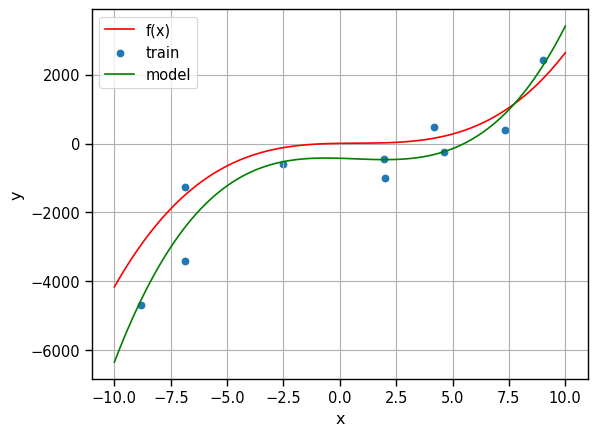

In [16]:
plt.plot(x, f(x), 'r', label='f(x)')
plt.scatter(x_train, y_train, label='train')
plt.plot(x, y_pred, color='g', label='model')
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.legend();

In [17]:
reg.coef_

array([-428.71768696,  -18.85244885,  -10.40644494,    5.0669525 ])

Полученная модель достаточно хорошо описывает данные, но не идеально. Посмотрим, что произойдет, если мы будем использовать многочлен 7-й степени в модели.

In [18]:
poly = PolynomialFeatures(degree=7)
x_train_poly = poly.fit_transform(x_train.reshape(-1, 1))
x_poly = poly.fit_transform(x.reshape(-1, 1))

reg.fit(x_train_poly, y_train)
y_pred = reg.predict(x_poly)
print(f'R2 на исходной функции = {r2_score(y_true,  y_pred):.3}')

R2 на исходной функции = -66.5


In [19]:
y_train_pred = reg.predict(x_train_poly)
print(f'R2 на обучающих данных = {r2_score(y_train, y_train_pred):.3}')

R2 на обучающих данных = 0.93


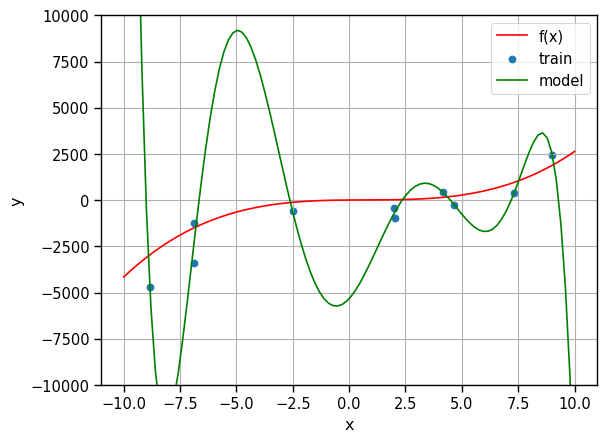

In [20]:
plt.plot(x, f(x), 'r', label='f(x)')
plt.scatter(x_train, y_train, label='train')
plt.plot(x, y_pred, color='g', label='model')
plt.ylim(-10000, 10000)
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.legend();

Наблюдаем еще одно явление в машинном обучении - **переобучение**. В этом случае алгоритм слишком сильно подогнан под обучающую выборку, и за счет этого будет давать неадекватные ответы на новых точках.

Таким образом, недообучение означает плохое качество на обучающей выборке и на новых данных, а переобучение - хорошее качество на обучающей выборке и плохое на новых данных.

Бороться с недообучением просто - нужно усложнять модель новыми признаками или заменять алгоритм на другой, более точный. В случае переобучения, как было сказано ранее, данные из обучающей выборки алгоритмом будут описываться хорошо, а новые данные - плохо, поэтому используя только обучающую выборку, невозможно заключить, хорошо обучен алгоритм или переобучен.

Одним из признаков переобучения в линейных моделях является получение больших по модулю весов. Посмотрим на веса последней модели.

In [21]:
reg.coef_

array([-5.33517849e+03,  1.34377044e+03,  1.00648329e+03, -2.25783737e+02,
       -3.10418219e+01,  6.49102882e+00,  2.42096782e-01, -4.79740378e-02])

Видим веса 2 и 3 порядков, в то время как в кубичесой модели и в исходной зависимости ничего подобного не было. Это и говорит нам о том, что в данном случае имеет место переобучение.

На этой особенности и основывается метод **регуляризации** для борьбы с переобучением (см. следующий блокнот).

# Документация

[PolynomialFeatures](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html)



# Задания

1. Загрузить датасет с категориями работников и средними заработными платами. Визуализировать данные. Обучить модель линейной регрессии на признаке `Level` и целевой переменной `Salary`. (2 балла)

2. Получить прогнозы и оценить точность предсказания с помощью метрики `r2_score`. (2 балла)

3. Обучить полиномиальную регрессию. Подобрать максимальную степень полинома такую, чтобы точность оказалась выше точности линейной регрессии, но переобучения не наблюдалось бы. (2 балла)

4. Построить график зависимости точности обучения полиномиальной регрессии от степени полинома. (2 балла)

In [22]:
!gdown 1heY_KcIfJ8fZSc5ZLgHci6cQRGMUuheM

Downloading...
From: https://drive.google.com/uc?id=1heY_KcIfJ8fZSc5ZLgHci6cQRGMUuheM
To: /content/salaries.csv
100% 248/248 [00:00<00:00, 840kB/s]


In [23]:
import pandas as pd

df = pd.read_csv('/content/salaries.csv')
df

,Position,Level,Salary
0,Business Analyst,1,30320
1,Junior Consultant,2,41650
2,Senior Consultant,3,60895
3,Manager,4,82840
4,Country Manager,5,109640
5,Region Manager,6,153785
6,Partner,7,232455
7,Senior Partner,8,4120555
8,C-level,9,5788450
9,CEO,10,9508000


In [24]:
x = df['Level'].values
x

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

In [25]:
y = df['Salary'].values
y

array([  30320,   41650,   60895,   82840,  109640,  153785,  232455,
       4120555, 5788450, 9508000])

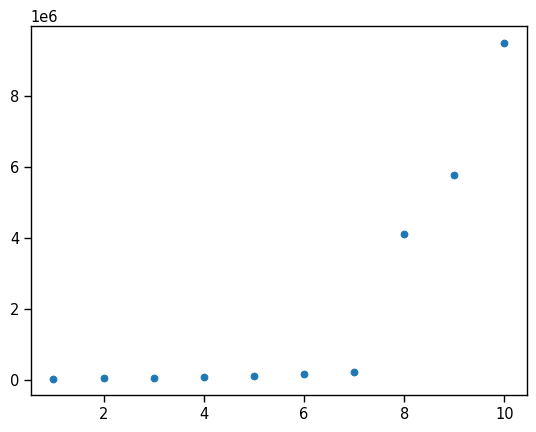

In [26]:
plt.scatter(x, y);

In [26]:
# код